# RetailRocket: experiment report

Purchase-target Hawkes (multi-type history) vs **scaled seasonal baseline**.

Baseline seasonality is **global hour-of-week (168 bins)** fitted on pooled *train* purchases across users; then each user gets its own `mu` via MLE scaling.


In [1]:
%matplotlib inline
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS_ROOT = ROOT / 'results/retailrocket'
print('ROOT:', ROOT)
print('RESULTS_ROOT:', RESULTS_ROOT)


ROOT: /Users/amosh239/repo/mkn/Hawk's proccess
RESULTS_ROOT: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket


In [2]:
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# Choose a run (defaults to the latest retailrocket-YYYYMMDD-HHMMSS folder).
RUN_ID = None # set to None to auto-pick latest
runs = sorted(RESULTS_ROOT.glob('retailrocket-*'))
if not runs:
    raise FileNotFoundError('No runs found. Run: .venv/bin/python scripts/run_real.py --dataset retailrocket')
RUN_DIR = (RESULTS_ROOT / RUN_ID) if RUN_ID else runs[-1]
SUMMARY_PATH = RUN_DIR / 'summary.csv'

df = pd.read_csv(SUMMARY_PATH)
print('RUN_DIR:', RUN_DIR)
print('rows:', len(df))
df.head(5)


RUN_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/retailrocket-20260127-121701
rows: 48


,seq_id,n_events,train_events,test_events,purchases_train,purchases_test,test_hours,ll_unit,ll_baseline,ll_hawkes,ll_gain,mu_baseline,mu_hawkes,mu,alpha_type_0,alpha_type_1,alpha_type_2
0,38015,861,651,210,2,0,307.903921,per_hour,-0.001540,-9.901414e-07,0.001539,0.001555,0.000001,0.000001,0.000000,5.0,0.000000
1,53842,862,795,67,61,3,98.382626,per_hour,-0.220704,1.805298e-02,0.238757,0.175402,0.000001,0.000001,0.030900,5.0,0.000000
2,57905,732,581,151,27,17,72.498278,per_hour,-0.441363,1.854372e-01,0.626800,0.090269,0.000001,0.000001,0.000000,5.0,0.000000
3,76757,1883,1326,557,114,71,287.491879,per_hour,-0.417345,1.349875e-01,0.552333,0.121546,0.000001,0.000001,0.015832,5.0,0.641913
4,85734,1461,985,476,12,3,936.124127,per_hour,-0.022161,-1.376417e-02,0.008397,0.010309,0.000001,0.000001,0.000000,5.0,0.000000


## Metrics
Notes:
- `ll_unit=per_hour`: test log-likelihood is normalized per hour of the test window.
- `ll_gain = ll_hawkes - ll_baseline`: **positive means Hawkes is better**.


In [3]:
wins = (df.ll_gain > 0)
p0 = (df.purchases_test == 0)

def pct(x):
    return 100.0 * float(x)

print('win rate (overall):', f'{pct(wins.mean()):.1f}%')
print('win rate (purchases_test==0):', f'{pct(wins[p0].mean()):.1f}%' if p0.any() else 'n/a')
print('win rate (purchases_test>0):', f'{pct(wins[~p0].mean()):.1f}%' if (~p0).any() else 'n/a')

print('purchases_test==0 share:', f'{pct(p0.mean()):.1f}%')
print('median ll_gain:', float(df.ll_gain.median()))
print('mean ll_gain:', float(df.ll_gain.mean()))
print('median test_hours:', float(df.test_hours.median()))


win rate (overall): 100.0%
win rate (purchases_test==0): 100.0%
win rate (purchases_test>0): 100.0%
purchases_test==0 share: 4.2%
median ll_gain: 0.37113743042181074
mean ll_gain: 0.4258672169789312
median test_hours: 168.08487694444443


## Plots

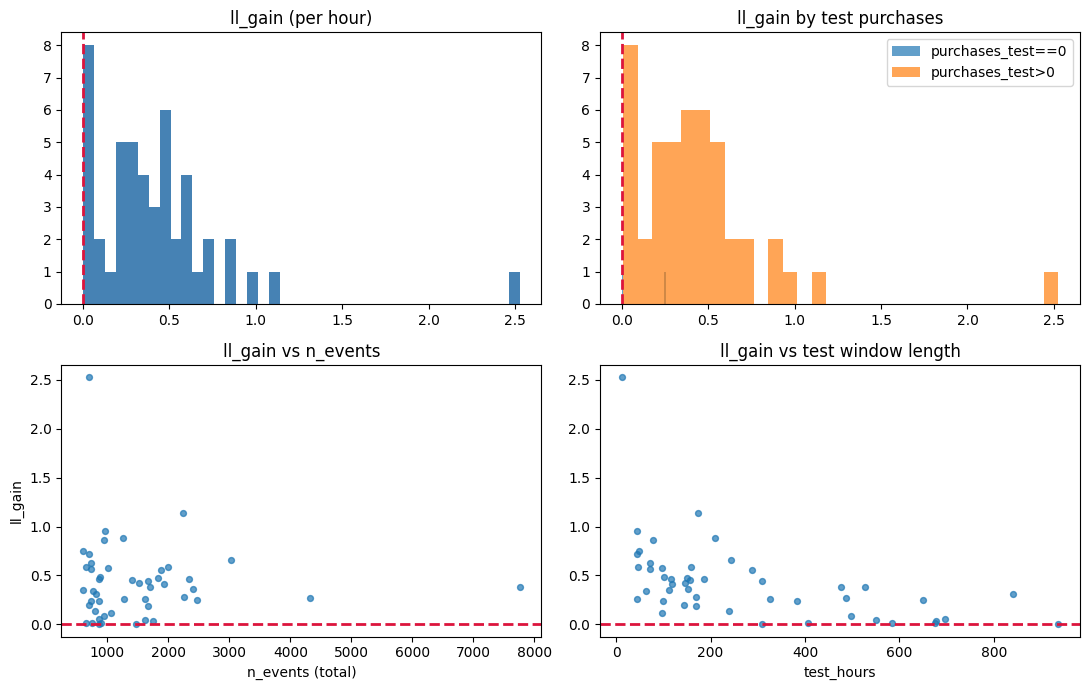

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

# ll_gain histogram
ax[0, 0].hist(df.ll_gain, bins=40, color='steelblue')
ax[0, 0].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0, 0].set_title('ll_gain (per hour)')

# ll_gain histogram by purchases_test==0
ax[0, 1].hist(df.loc[p0, 'll_gain'], bins=30, alpha=0.7, label='purchases_test==0')
ax[0, 1].hist(df.loc[~p0, 'll_gain'], bins=30, alpha=0.7, label='purchases_test>0')
ax[0, 1].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0, 1].set_title('ll_gain by test purchases')
ax[0, 1].legend()

# scatter: ll_gain vs n_events
ax[1, 0].scatter(df.n_events, df.ll_gain, s=18, alpha=0.7)
ax[1, 0].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1, 0].set_xlabel('n_events (total)')
ax[1, 0].set_ylabel('ll_gain')
ax[1, 0].set_title('ll_gain vs n_events')

# scatter: ll_gain vs test_hours
ax[1, 1].scatter(df.test_hours, df.ll_gain, s=18, alpha=0.7)
ax[1, 1].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1, 1].set_xlabel('test_hours')
ax[1, 1].set_title('ll_gain vs test window length')

plt.tight_layout()


## Fitted alpha (by event type)
For the purchase-target model we keep 3 excitation parameters:
- `alpha_type_0` (view -> purchase)
- `alpha_type_1` (addtocart -> purchase)
- `alpha_type_2` (transaction -> purchase)


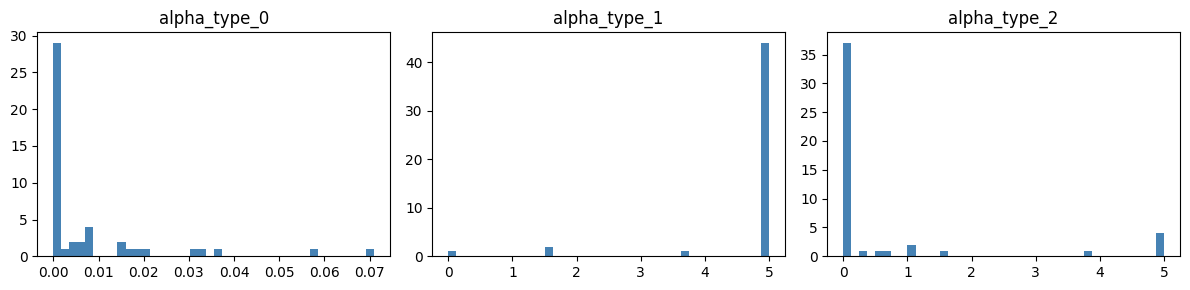

In [5]:
alpha_cols = ['alpha_type_0', 'alpha_type_1', 'alpha_type_2']
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, c in enumerate(alpha_cols):
    ax[i].hist(df[c].values, bins=40, color='steelblue')
    ax[i].set_title(c)
plt.tight_layout()


## Best / worst sequences

In [6]:
cols = ['seq_id', 'n_events', 'purchases_train', 'purchases_test', 'test_hours', 'll_gain']
print('Top 10 by ll_gain:')
display(df.sort_values('ll_gain', ascending=False)[cols].head(10))
print('Bottom 10 by ll_gain:')
display(df.sort_values('ll_gain', ascending=True)[cols].head(10))


Top 10 by ll_gain:


,seq_id,n_events,purchases_train,purchases_test,test_hours,ll_gain
37,974226,694,39,6,12.005789,2.524577
25,684514,2246,106,83,173.181284,1.135198
9,198270,956,76,28,43.976837,0.955398
28,757355,1251,27,74,210.069125,0.884342
17,389532,937,23,29,78.293901,0.865874
39,1093035,606,51,17,48.373686,0.750767
15,371604,701,33,15,43.586520,0.721359
6,152963,3024,278,71,243.104738,0.660209
2,57905,732,27,17,72.498278,0.626800
33,861299,1991,158,30,159.503474,0.587187


Bottom 10 by ll_gain:


,seq_id,n_events,purchases_train,purchases_test,test_hours,ll_gain
0,38015,861,2,0,307.903921,0.001539
4,85734,1461,12,3,936.124127,0.008397
31,825321,895,3,1,583.640773,0.011239
47,1336835,744,6,3,674.910046,0.013979
23,591869,650,9,1,406.594703,0.018872
13,316850,1752,16,4,676.719404,0.033610
19,518659,1614,25,15,549.594865,0.043746
44,1165148,858,16,11,695.496376,0.052211
40,1126569,937,25,10,497.668133,0.080664
27,737053,1055,8,2,96.373168,0.112651


## Why so many `purchases_test==0`?
Because purchases are rare. The notebook `notebooks/retailrocket_dataset_qa.ipynb` shows how this depends on `train_ratio` and `min_events`.

If you want more test purchases, try a larger test window (smaller train_ratio), e.g.:
```bash
.venv/bin/python scripts/run_real.py --dataset retailrocket --train-ratio 0.6 --min-events 30 --min-purchases-train 1 --max-seqs 500
```
